In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
m = 5 # parametr rozkłdu Bin(m, p)
ns = [20, 50, 100] 
ps = [0.1, 0.3, 0.5, 0.7, 0.9] # paametryu rozkładu Bin(m, p)
T = 10**4 

In [36]:
import os

BASE_DIR = '../plots/zad1'
os.makedirs(BASE_DIR, exist_ok=True)
boxplot_dir = os.path.join(BASE_DIR, 'boxploty')
os.makedirs(boxplot_dir, exist_ok=True)
bias_plot_dir = os.path.join(BASE_DIR, 'wykresy_statystyk')
os.makedirs(bias_plot_dir, exist_ok=True)
stats_dir = os.path.join(BASE_DIR, 'statystyki')
os.makedirs(stats_dir, exist_ok=True)
print(f"Przygotowano foldery w: {BASE_DIR}")

Przygotowano foldery w: ../plots/zad1


In [37]:
from scipy.stats import binom

def estimator_p(xs): # próba -> estymator p
  return np.mean(xs) / m

def estimator(xs): # próba -> estymator P(x>=3)
  return binom.sf(k=2, n=m, p=estimator_p(xs))


In [38]:
def gen_sample(n, p): # parametry -> próba
  return np.random.binomial(m, p, n)

In [39]:
def statistics(estimates, n, m, p): # wyniki esymatora dla wszyskich eksperymentów, (rozmiar próby per eksperyment, parametr m i p) -> bias, mse, var
  bias = np.mean(estimates) - p
  mse = np.mean((estimates - p)**2)
  var = np.var(estimates)
  return {"BIAS": bias, "MSE": mse, "VAR": var}

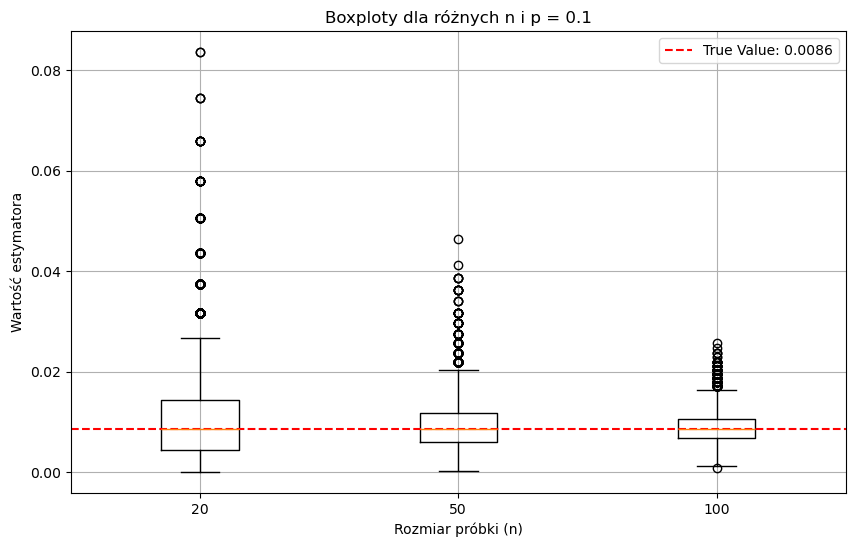

Zapisano boxplot dla p=0.1 do: ../plots/zad1/boxploty/boxplot_p_1.png


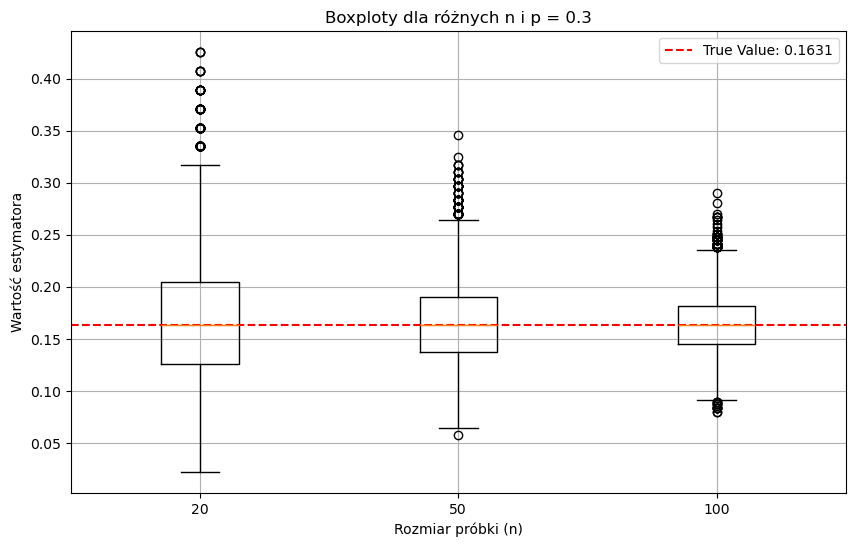

Zapisano boxplot dla p=0.3 do: ../plots/zad1/boxploty/boxplot_p_3.png


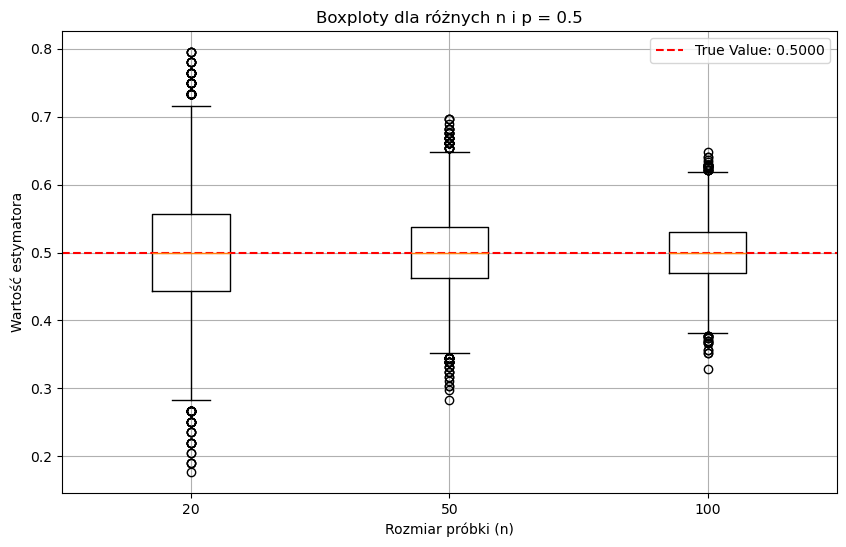

Zapisano boxplot dla p=0.5 do: ../plots/zad1/boxploty/boxplot_p_5.png


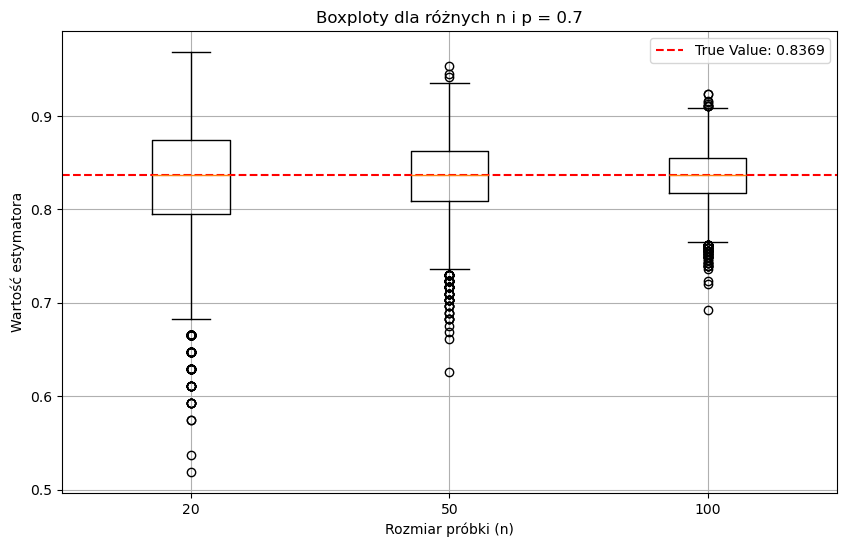

Zapisano boxplot dla p=0.7 do: ../plots/zad1/boxploty/boxplot_p_7.png


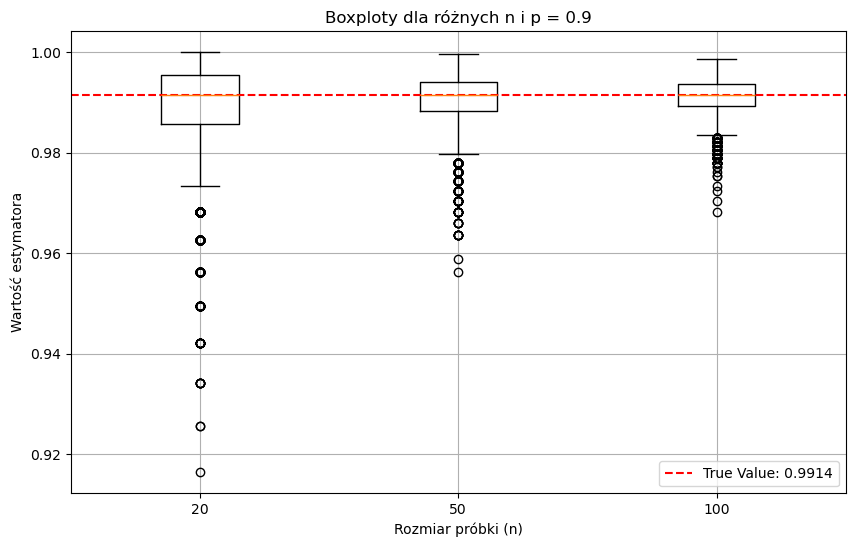

Zapisano boxplot dla p=0.9 do: ../plots/zad1/boxploty/boxplot_p_9.png


In [40]:
from scipy.stats import binom

stats = {"BIAS": {}, "MSE": {}, "VAR": {}}
for p in ps:
  estimates_for_p = {}
  plt.figure(figsize=(10, 6))

  true_value = binom.sf(k=2, n=m, p=p)

  # Initialize dictionaries for the current p within stats
  stats["BIAS"][p] = {}
  stats["MSE"][p] = {}
  stats["VAR"][p] = {}

  for n in ns:
    estimates = np.array([estimator(gen_sample(n, p)) for _ in range(T)])

    # Calculate statistics for the current n and p using the true_value
    calculated_stats = statistics(estimates, n, m, true_value)

    # Store the calculated statistics
    stats["BIAS"][p][n] = calculated_stats["BIAS"]
    stats["MSE"][p][n] = calculated_stats["MSE"]
    stats["VAR"][p][n] = calculated_stats["VAR"]

    estimates_for_p[n] = estimates

  plt.boxplot(estimates_for_p.values(), tick_labels=estimates_for_p.keys())
  plt.axhline(true_value, color='red', linestyle='--', label=f'True Value: {true_value:.4f}')
  plt.title(f'Boxploty dla różnych n i p = {p}')
  plt.xlabel('Rozmiar próbki (n)')
  plt.ylabel('Wartość estymatora')
  plt.grid(True)
  plt.legend()

  filename = os.path.join(boxplot_dir, f'boxplot_p_{int(p*10)}.png')
  plt.savefig(filename)
  plt.show()
  plt.close() 
  print(f"Zapisano boxplot dla p={p} do: {filename}")

In [41]:
plt.figure(figsize=(10, 6))

for n in ns:
  bias_values = [stats['BIAS'][p_val][n] for p_val in ps]
  plt.plot(ps, bias_values, marker='o', label=f'n={n}')

plt.title('Bias estymatora $P(X>= 3)$')
plt.xlabel('$p$')
plt.ylabel('Bias')
plt.grid(True)
plt.legend()
filename = os.path.join(bias_plot_dir, 'bias_vs_p.png')
plt.savefig(filename)
plt.close()
print(f"Zapisano wykres Biasu do: {filename}")

Zapisano wykres Biasu do: ../plots/zad1/wykresy_statystyk/bias_vs_p.png


In [42]:
plt.figure(figsize=(10, 6))

for n in ns:
  mse_values = [stats['MSE'][p_val][n] for p_val in ps]
  plt.plot(ps, mse_values, marker='o', label=f'n={n}')

plt.title('MSE estymatora $P(X>= 3)$')
plt.xlabel('$p$')
plt.ylabel('MSE')
plt.grid(True)
plt.legend()
filename = os.path.join(bias_plot_dir, 'mse_vs_p.png')
plt.savefig(filename)
plt.close()
print(f"Zapisano wykres MSE do: {filename}")

Zapisano wykres MSE do: ../plots/zad1/wykresy_statystyk/mse_vs_p.png


In [43]:
plt.figure(figsize=(10, 6))

for n in ns:
  var_values = [stats['VAR'][p_val][n] for p_val in ps]
  plt.plot(ps, var_values, marker='o', label=f'n={n}')

plt.title('Wariancja estymatora $P(X>= 3)$')
plt.xlabel('$p$')
plt.ylabel('Wariancja')
plt.grid(True)
plt.legend()
filename = os.path.join(bias_plot_dir, 'variance_vs_p.png')
plt.savefig(filename)
plt.close()
print(f"Zapisano wykres Wariancji do: {filename}")

Zapisano wykres Wariancji do: ../plots/zad1/wykresy_statystyk/variance_vs_p.png


In [44]:
bias_df = pd.DataFrame(stats['BIAS']).T.rename_axis('p').rename_axis('n', axis=1)
mse_df = pd.DataFrame(stats['MSE']).T.rename_axis('p').rename_axis('n', axis=1)
var_df = pd.DataFrame(stats['VAR']).T.rename_axis('p').rename_axis('n', axis=1)

bias_df.to_csv(os.path.join(stats_dir, 'bias.csv'))
mse_df.to_csv(os.path.join(stats_dir, 'mse.csv'))
var_df.to_csv(os.path.join(stats_dir, 'var.csv'))
print(f"Zapisano tabele statystyk (CSV) w folderze: {stats_dir}")

Zapisano tabele statystyk (CSV) w folderze: ../plots/zad1/statystyki
